In [1]:
pip install opencv-python


  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from IPython.display import display
from sklearn.cluster import KMeans

In [3]:
img1 = cv2.imread("Images/Problem1.jpg")
img1

array([[[189, 205, 211],
        [179, 195, 202],
        [169, 188, 194],
        ...,
        [204, 228, 231],
        [207, 231, 234],
        [213, 237, 240]],

       [[189, 205, 211],
        [179, 195, 202],
        [169, 188, 194],
        ...,
        [203, 227, 230],
        [206, 230, 233],
        [212, 236, 239]],

       [[189, 205, 211],
        [179, 195, 202],
        [169, 188, 194],
        ...,
        [203, 227, 230],
        [206, 230, 233],
        [212, 236, 239]],

       ...,

       [[163, 183, 191],
        [161, 181, 190],
        [164, 184, 192],
        ...,
        [169, 197, 204],
        [171, 198, 205],
        [172, 199, 206]],

       [[160, 180, 188],
        [160, 180, 188],
        [165, 185, 193],
        ...,
        [169, 197, 204],
        [171, 198, 205],
        [172, 199, 206]],

       [[159, 179, 187],
        [160, 180, 188],
        [166, 186, 194],
        ...,
        [169, 197, 204],
        [171, 198, 205],
        [172, 199, 206]]

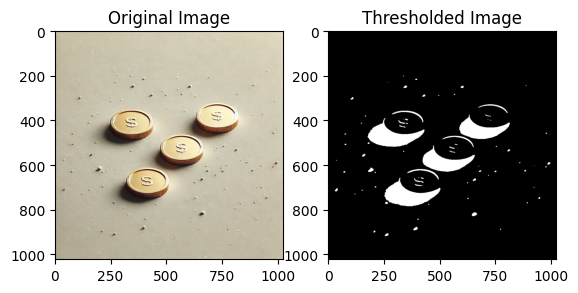

In [4]:
gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 0)
_, thresholded = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img1.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

# Display the results
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title("Thresholded Image")
plt.imshow(thresholded, cmap="gray")

Problem2

In [5]:
img2 = cv2.imread("Images/Problem2.jpg")
img2

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

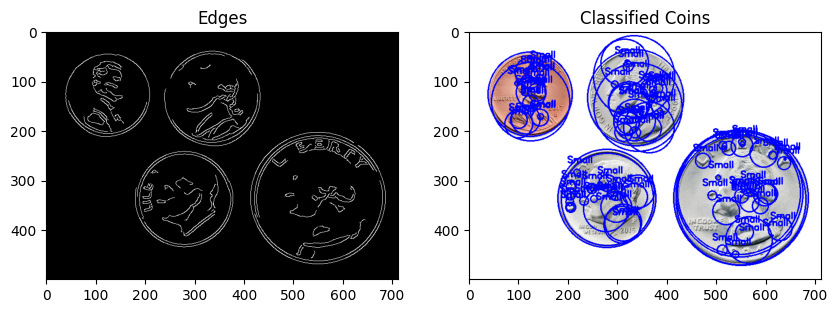

Small coins: 90
Medium coins: 0
Large coins: 0


In [6]:
gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 0)
edges = cv2.Canny(blurred, 30, 150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img2.copy()
small_count = 0
medium_count = 0
large_count = 0


for contour in contours:

    area = cv2.contourArea(contour)
    
  
    if area < 1000:  
        category = "Small"
        color = (255, 0, 0)  
        small_count += 1
    elif 1000 <= area < 3000:
        category = "Medium"
        color = (0, 255, 0)
        medium_count += 1
    else: 
        category = "Large"
        color = (0, 0, 255)  
        large_count += 1
    

    ((x, y), radius) = cv2.minEnclosingCircle(contour)
    center = (int(x), int(y))
    cv2.circle(output, center, int(radius), color, 2)
    cv2.putText(output, category, (int(x) - 20, int(y) - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Edges")
plt.imshow(edges, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Classified Coins")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

plt.show()


print(f"Small coins: {small_count}")
print(f"Medium coins: {medium_count}")
print(f"Large coins: {large_count}")

Problem 3

In [7]:
img3 = cv2.imread("Images/Problem3.jpg")
img3

array([[[150, 154, 154],
        [193, 198, 197],
        [187, 195, 192],
        ...,
        [ 88,  82,  85],
        [104,  99, 102],
        [102,  96,  99]],

       [[169, 175, 176],
        [184, 191, 190],
        [157, 168, 164],
        ...,
        [ 79,  73,  76],
        [ 73,  67,  70],
        [ 89,  83,  87]],

       [[170, 182, 185],
        [163, 175, 175],
        [148, 160, 158],
        ...,
        [ 82,  76,  80],
        [ 86,  80,  83],
        [100,  94,  97]],

       ...,

       [[159, 161, 161],
        [159, 162, 159],
        [192, 193, 191],
        ...,
        [191, 212, 216],
        [178, 205, 207],
        [161, 190, 192]],

       [[132, 136, 138],
        [143, 147, 147],
        [168, 173, 172],
        ...,
        [181, 200, 204],
        [171, 195, 198],
        [196, 222, 225]],

       [[126, 132, 133],
        [108, 114, 116],
        [130, 137, 136],
        ...,
        [171, 188, 192],
        [201, 225, 228],
        [197, 223, 226]]

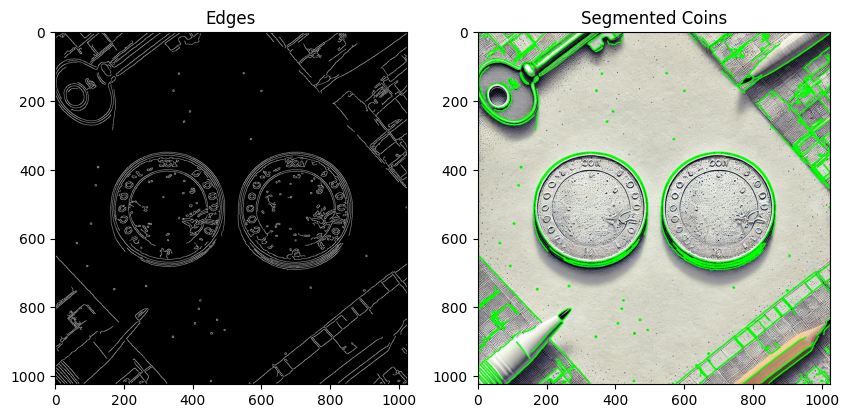

In [8]:
gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 0)
edges = cv2.Canny(blurred, 30, 150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


output = img3.copy()
for contour in contours:
    
    cv2.drawContours(output, [contour], -1, (0, 255, 0), 2)


plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Edges")
plt.imshow(edges, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Segmented Coins")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

plt.show()

Problem 4

In [9]:
img4 = cv2.imread("Images/Problem4.png")
img4

array([[[188, 193, 185],
        [166, 170, 164],
        [ 27,  28,  25],
        ...,
        [ 27,  49,  45],
        [ 14,  35,  34],
        [ 13,  34,  33]],

       [[187, 191, 184],
        [154, 158, 153],
        [ 21,  22,  19],
        ...,
        [ 11,  33,  29],
        [ 30,  49,  48],
        [ 13,  31,  31]],

       [[206, 211, 204],
        [128, 132, 127],
        [ 23,  24,  22],
        ...,
        [ 19,  43,  40],
        [ 14,  30,  30],
        [  1,  14,  14]],

       ...,

       [[112, 100,  77],
        [123, 110,  87],
        [122, 109,  86],
        ...,
        [151, 151, 151],
        [161, 163, 163],
        [ 81,  83,  83]],

       [[103,  90,  67],
        [166, 153, 130],
        [139, 127, 104],
        ...,
        [188, 199, 200],
        [169, 180, 181],
        [106, 118, 118]],

       [[114, 101,  78],
        [ 98,  86,  63],
        [124, 111,  88],
        ...,
        [ 48,  64,  63],
        [ 53,  69,  69],
        [ 60,  76,  76]]

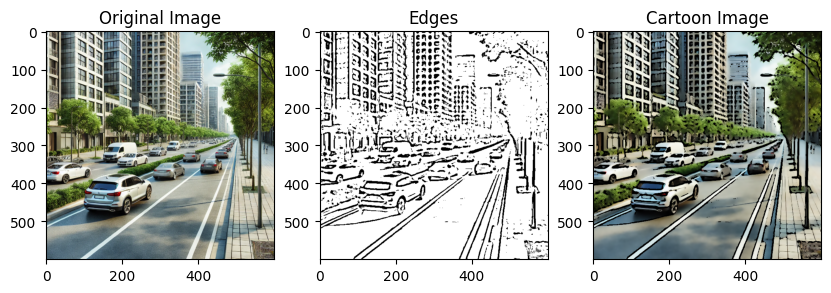

In [10]:
img4 = cv2.resize(img4, (600, 600))
gray = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray, 7)
edges = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 10
)
color = cv2.bilateralFilter(img4, d=9, sigmaColor=75, sigmaSpace=75)


cartoon = cv2.bitwise_and(color, color, mask=edges)


plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title("Edges")
plt.imshow(edges, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Cartoon Image")
plt.imshow(cv2.cvtColor(cartoon, cv2.COLOR_BGR2RGB))

plt.show()


Problem 5

In [11]:
img5 = cv2.imread("Images/Problem5.jpg")
img5

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [12]:
# pip install scikit-learn

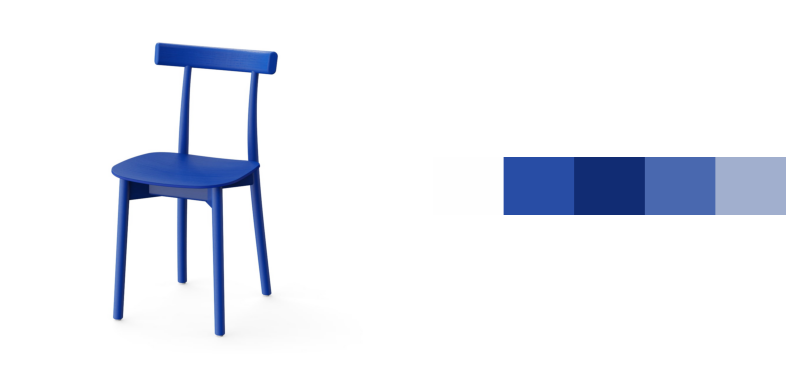

In [13]:
img5 = cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)
pixels = img5.reshape(-1, 3)

kmeans = KMeans(n_clusters=5, n_init=10)  
kmeans.fit(pixels)
colors = kmeans.cluster_centers_.astype(int)

palette = np.zeros((50, 300, 3), dtype="uint8")
steps = 300 // len(colors)
for i, color in enumerate(colors):
    palette[:, i * steps:(i + 1) * steps] = color

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img5)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(palette)
plt.axis("off")
plt.show()